In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve
                            )
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib
import os

In [2]:
os.makedirs("outputs", exist_ok=True)
SEED = 42
np.random.seed(SEED)


In [3]:
df = pd.read_csv("german_credit_data.csv", index_col=0)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
# Shows a list of all unique values
print(df['Checking account'].unique())

df = df.drop(columns="Checking account")

<ArrowStringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str


In [5]:
print("\nBasic Info")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass distribution (Risk):")
print(df["Risk"].value_counts())


Basic Info
Age                int64
Sex                  str
Job                int64
Housing              str
Saving accounts      str
Credit amount      int64
Duration           int64
Purpose              str
Risk                 str
dtype: object

Missing values:
Age                  0
Sex                  0
Job                  0
Housing              0
Saving accounts    183
Credit amount        0
Duration             0
Purpose              0
Risk                 0
dtype: int64

Class distribution (Risk):
Risk
good    700
bad     300
Name: count, dtype: int64


In [6]:
df["Saving accounts"] = df["Saving accounts"].fillna(df["Saving accounts"].mode()[0])

In [7]:
print("Missing values after fill:", df.isnull().sum().sum())

Missing values after fill: 0


    Saved: outputs/eda_distributions.png


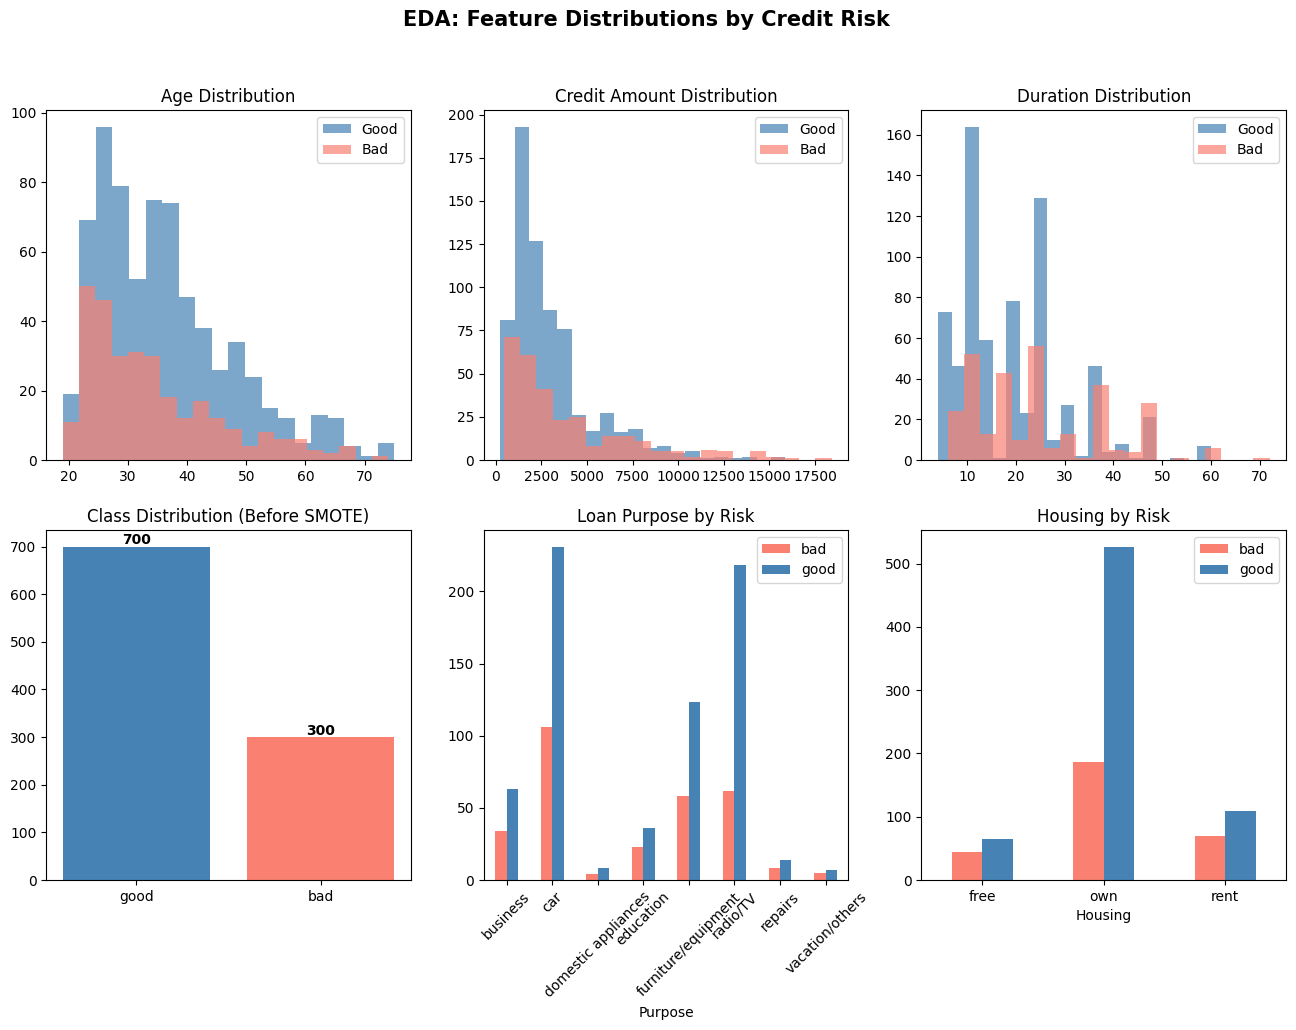

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("EDA: Feature Distributions by Credit Risk", fontsize=15, fontweight="bold")
 
# Age
axes[0, 0].hist(df[df["Risk"] == "good"]["Age"], bins=20, alpha=0.7, label="Good", color="steelblue")
axes[0, 0].hist(df[df["Risk"] == "bad"]["Age"],  bins=20, alpha=0.7, label="Bad",  color="salmon")
axes[0, 0].set_title("Age Distribution"); axes[0, 0].legend()

# Credit Amount
axes[0, 1].hist(df[df["Risk"] == "good"]["Credit amount"], bins=20, alpha=0.7, label="Good", color="steelblue")
axes[0, 1].hist(df[df["Risk"] == "bad"]["Credit amount"],  bins=20, alpha=0.7, label="Bad",  color="salmon")
axes[0, 1].set_title("Credit Amount Distribution"); axes[0, 1].legend()

# Duration
axes[0, 2].hist(df[df["Risk"] == "good"]["Duration"], bins=20, alpha=0.7, label="Good", color="steelblue")
axes[0, 2].hist(df[df["Risk"] == "bad"]["Duration"],  bins=20, alpha=0.7, label="Bad",  color="salmon")
axes[0, 2].set_title("Duration Distribution"); axes[0, 2].legend()
 
# Class distribution
risk_counts = df["Risk"].value_counts()
axes[1, 0].bar(risk_counts.index, risk_counts.values, color=["steelblue", "salmon"])
axes[1, 0].set_title("Class Distribution (Before SMOTE)")
for i, v in enumerate(risk_counts.values):
    axes[1, 0].text(i, v + 5, str(v), ha="center", fontweight="bold")
 
# Purpose
purpose_risk = df.groupby(["Purpose", "Risk"]).size().unstack(fill_value=0)
purpose_risk.plot(kind="bar", ax=axes[1, 1], color=["salmon", "steelblue"], rot=45)
axes[1, 1].set_title("Loan Purpose by Risk"); axes[1, 1].legend()
 
# Housing
housing_risk = df.groupby(["Housing", "Risk"]).size().unstack(fill_value=0)
housing_risk.plot(kind="bar", ax=axes[1, 2], color=["salmon", "steelblue"], rot=0)
axes[1, 2].set_title("Housing by Risk"); axes[1, 2].legend()
# plt.close()
print("    Saved: outputs/eda_distributions.png")
 


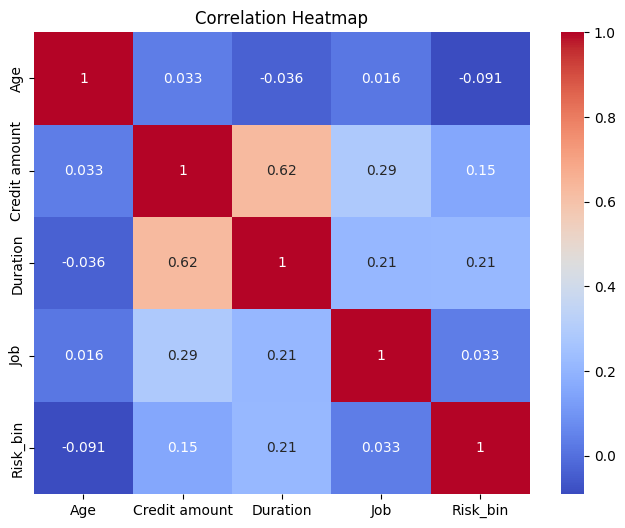

In [9]:

num_df = df[["Age", "Credit amount", "Duration", "Job"]].copy()
num_df["Risk_bin"] = df["Risk"].map({"good": 0, "bad": 1})

plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

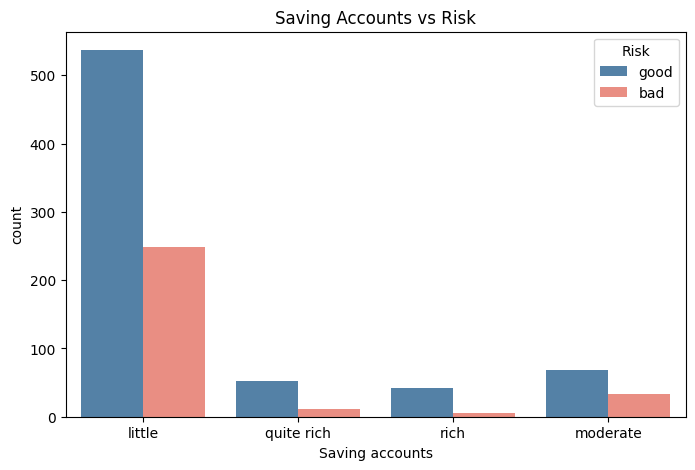

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Saving accounts", hue="Risk", palette={"good": "steelblue", "bad": "salmon"})

plt.title("Saving Accounts vs Risk")
plt.show()

In [11]:
def cap_outliers(df, col):
    # 1. Find the boundaries
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    # 2. Count the 'weird' values
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    # 3. Squish values into the range [lower, upper]
    df[col] = df[col].clip(lower, upper)
    
    print(f"Fixed {outliers} outliers in {col}")
    return df

In [12]:
for col in ["Age", "Credit amount", "Duration"]:
    df = cap_outliers(df, col)

Fixed 23 outliers in Age
Fixed 72 outliers in Credit amount
Fixed 70 outliers in Duration


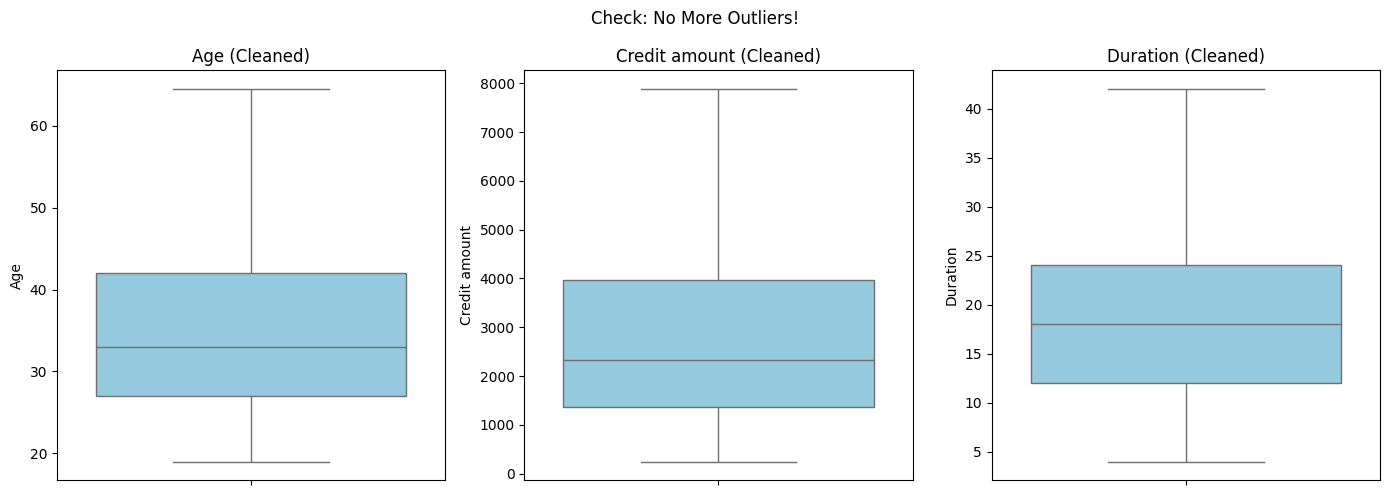

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cols = ["Age", "Credit amount", "Duration"]
for i, col in enumerate(cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color="skyblue")
    axes[i].set_title(f"{col} (Cleaned)")

plt.suptitle("Check: No More Outliers!")
plt.tight_layout()
plt.show()

In [14]:
 
df_enc = df.copy()
le_dict = {}
 
cat_cols = ["Sex", "Housing", "Saving accounts", "Purpose", "Risk"]
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    le_dict[col] = le
    print(f"    {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    Sex: {'female': np.int64(0), 'male': np.int64(1)}
    Housing: {'free': np.int64(0), 'own': np.int64(1), 'rent': np.int64(2)}
    Saving accounts: {'little': np.int64(0), 'moderate': np.int64(1), 'quite rich': np.int64(2), 'rich': np.int64(3)}
    Purpose: {'business': np.int64(0), 'car': np.int64(1), 'domestic appliances': np.int64(2), 'education': np.int64(3), 'furniture/equipment': np.int64(4), 'radio/TV': np.int64(5), 'repairs': np.int64(6), 'vacation/others': np.int64(7)}
    Risk: {'bad': np.int64(0), 'good': np.int64(1)}


In [15]:
# Features & Target
X = df_enc.drop("Risk", axis=1)
y = df_enc["Risk"]   # 0 = bad, 1 = good
 
print(f"\n    X shape: {X.shape}")
print(f"    y distribution before SMOTE: {dict(pd.Series(y).value_counts())}")


    X shape: (1000, 8)
    y distribution before SMOTE: {1: np.int64(700), 0: np.int64(300)}


Balanced counts:
Risk
0    700
1    700
Name: count, dtype: int64


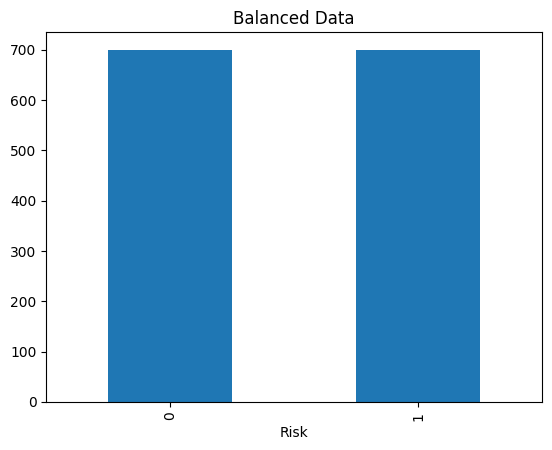

In [16]:

df = pd.concat([X, y], axis=1)

max_size = df[y.name].value_counts().max()
df_balanced = df.groupby(y.name).sample(n=max_size, replace=True, random_state=42)

# 3. Split back into X and y
X_resampled = df_balanced.drop(columns=[y.name])
y_resampled = df_balanced[y.name]

print(f"Balanced counts:\n{y_resampled.value_counts()}")

# --- Save Plot ---
os.makedirs("outputs", exist_ok=True)
ax = y_resampled.value_counts().plot(kind='bar', title='Balanced Data')
ax.figure.savefig("outputs/smote_balance.png")

In [17]:
print("Train / Test Split (80/20 Stratified) ...")
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=SEED, stratify=y_resampled
)
print(f"    Train: {X_train.shape}  |  Test: {X_test.shape}")
 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train / Test Split (80/20 Stratified) ...
    Train: (1120, 8)  |  Test: (280, 8)


In [18]:
X_train_sc

array([[-1.06382528,  0.69671453, -2.8325244 , ...,  2.01234499,
        -1.41810406, -0.9171508 ],
       [-0.7876778 ,  0.69671453,  0.16598914, ..., -0.8912855 ,
         0.25945596, -0.9171508 ],
       [-0.7876778 ,  0.69671453,  0.16598914, ..., -0.81262548,
         0.25945596, -1.417984  ],
       ...,
       [ 1.69764949,  0.69671453,  1.66524591, ...,  2.00479406,
        -0.85891739,  0.58534881],
       [-0.7876778 ,  0.69671453,  0.16598914, ..., -0.51406506,
        -1.04531294,  0.58534881],
       [-0.7876778 ,  0.69671453, -1.33326763, ..., -1.14160691,
        -0.85891739,  1.08618201]], shape=(1120, 8))

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, C=0.5, random_state=SEED),
  
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=SEED),

    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2, random_state=SEED),

    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED),
    
    "AdaBoost":            AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=SEED),
    
    "KNN":                 KNeighborsClassifier(n_neighbors=11, weights='distance'),

    "SVM":                 SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED),
    "XGBoost":             XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.01, 
                                         subsample=0.8, colsample_bytree=0.8,
                                         eval_metric="logloss", random_state=SEED, verbosity=0),
}

In [20]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, model in models.items():     
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    acc= accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cvs = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring="accuracy")
    results[name] = {"model": model, "accuracy": acc, "auc": auc,
                    "cv_mean": cvs.mean(), "cv_std": cvs.std(),
                    "y_pred": y_pred, "y_prob": y_prob}
    print(f" {name:<25} Acc={acc:.4f}  AUC={auc:.4f}  CV={cvs.mean():.4f}")



 Logistic Regression       Acc=0.5679  AUC=0.6362  CV=0.6205
 Decision Tree             Acc=0.7857  AUC=0.8631  CV=0.7679
 Random Forest             Acc=0.8643  AUC=0.9276  CV=0.8402
 Gradient Boosting         Acc=0.8286  AUC=0.8929  CV=0.8411
 AdaBoost                  Acc=0.5929  AUC=0.6861  CV=0.6188
 KNN                       Acc=0.8750  AUC=0.9767  CV=0.8527
 SVM                       Acc=0.7179  AUC=0.8041  CV=0.6866
 XGBoost                   Acc=0.8000  AUC=0.8729  CV=0.8107


                 Model  Accuracy       AUC   CV_Mean
5                  KNN     0.875  0.976684  0.852679
2        Random Forest  0.864286  0.927551  0.840179
3    Gradient Boosting  0.828571  0.892857  0.841071
7              XGBoost       0.8  0.872857  0.810714
1        Decision Tree  0.785714  0.863138  0.767857
6                  SVM  0.717857  0.804082  0.686607
4             AdaBoost  0.592857  0.686097   0.61875
0  Logistic Regression  0.567857  0.636173  0.620536


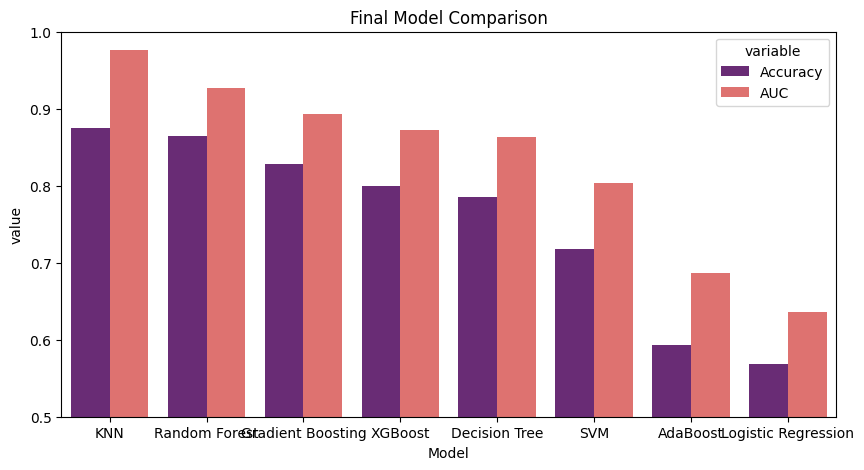

In [21]:
comp_df = pd.DataFrame(results).T[['accuracy', 'auc', 'cv_mean']].reset_index()
comp_df.columns = ['Model', 'Accuracy', 'AUC', 'CV_Mean']
comp_df = comp_df.sort_values("AUC", ascending=False)

print(comp_df)
# We "melt" the data to make it easy for Seaborn to plot side-by-side
tidy_df = comp_df.melt(id_vars="Model", value_vars=["Accuracy", "AUC"])

plt.figure(figsize=(10, 5))
sns.barplot(data=tidy_df, x="Model", y="value", hue="variable", palette="magma")
plt.ylim(0.5, 1.0)
plt.title("Final Model Comparison")
plt.show()

In [22]:
print("Detailed Random Fores Evaluation ...")
rf = results["Random Forest"]
print(classification_report(y_test, rf["y_pred"], target_names=["bad","good"]))

Detailed Random Fores Evaluation ...
              precision    recall  f1-score   support

         bad       0.85      0.88      0.87       140
        good       0.88      0.85      0.86       140

    accuracy                           0.86       280
   macro avg       0.86      0.86      0.86       280
weighted avg       0.86      0.86      0.86       280



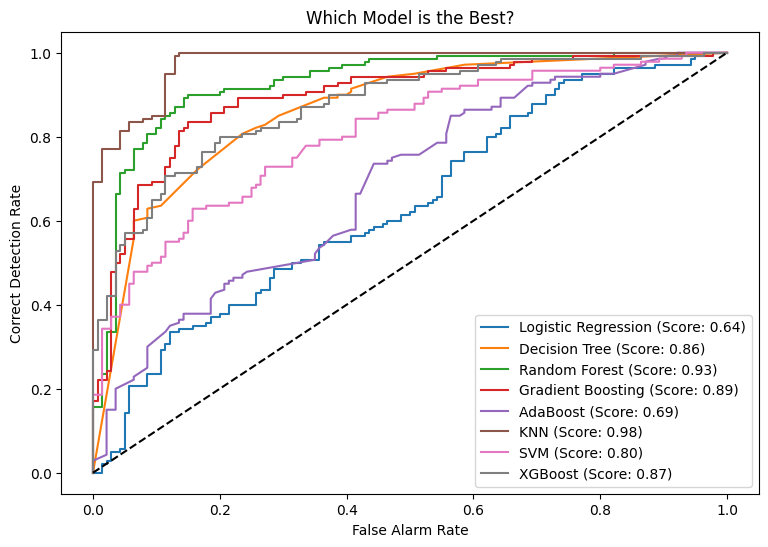

In [23]:

plt.figure(figsize=(9, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    
    plt.plot(fpr, tpr, label=f"{name} (Score: {res['auc']:.2f})")

plt.plot([0, 1], [0, 1], color="black", linestyle="--") # The "Coin Flip" line
plt.xlabel("False Alarm Rate")
plt.ylabel("Correct Detection Rate")
plt.title("Which Model is the Best?")
plt.legend()
plt.show()

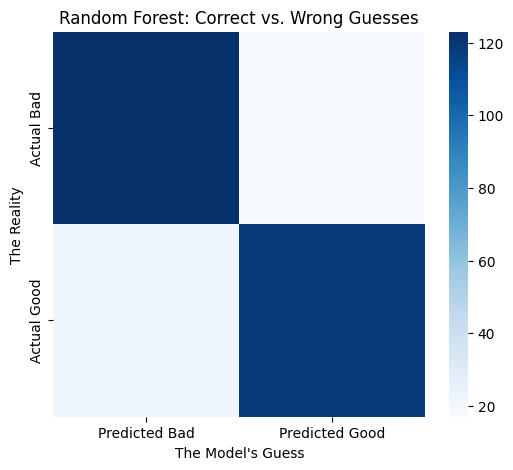

In [24]:
cm = confusion_matrix(y_test, results["Random Forest"]["y_pred"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, fmt="d", cmap="Blues", 
            xticklabels=["Predicted Bad", "Predicted Good"], 
            yticklabels=["Actual Bad", "Actual Good"])

plt.title("Random Forest: Correct vs. Wrong Guesses")
plt.ylabel("The Reality")
plt.xlabel("The Model's Guess")
plt.show()

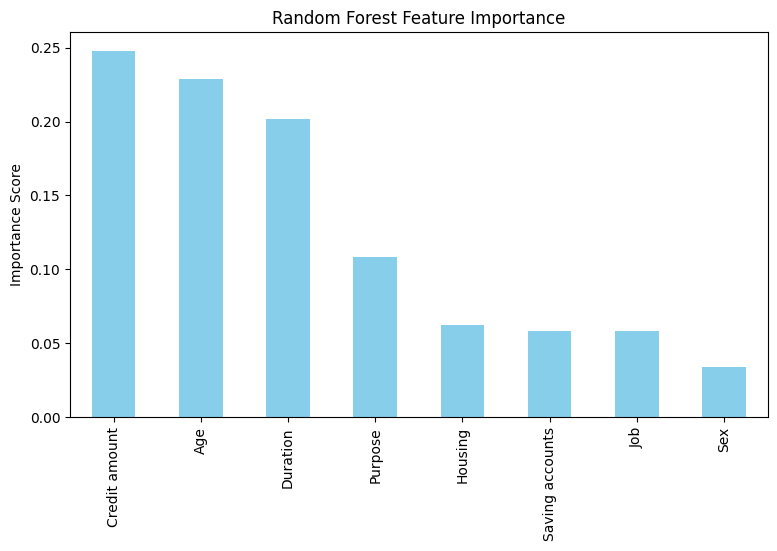

<Figure size 640x480 with 0 Axes>

In [25]:

rf_model = results["Random Forest"]["model"]
importance = pd.Series(rf_model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

importance.plot(kind="bar", figsize=(9, 5), color="skyblue")

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance Score")
plt.show()
plt.savefig("outputs/rf_feature_importance.png", dpi=120, bbox_inches="tight")
# plt.close()

 

In [26]:
print("Saving artifacts ...")
joblib.dump(rf_model,"outputs/rf_model.pkl")
joblib.dump(scaler,"outputs/scaler.pkl")
joblib.dump(le_dict,"outputs/le_dict.pkl")
joblib.dump(X.columns.tolist(),"outputs/feature_names.pkl")
print("Saved: rf_model.pkl, scaler.pkl, le_dict.pkl, feature_names.pkl")
 
 

Saving artifacts ...
Saved: rf_model.pkl, scaler.pkl, le_dict.pkl, feature_names.pkl
